# Staggered Difference-in-Differences

This notebook demonstrates the `StaggeredDifferenceInDifferences` estimator in CausalPy, which handles {term}`Staggered Difference-in-Differences` settings where different units receive treatment at different times.

## The Staggered Adoption Problem

In many real-world settings, treatment is not applied to all units at the same time. Instead, different cohorts of units adopt treatment at different times. This creates a "staggered adoption" pattern.

### Why Standard Two-Way Fixed Effects (TWFE) Can Fail

The standard TWFE regression with a single treatment indicator:

$$Y_{it} = \alpha_i + \lambda_t + \tau D_{it} + \varepsilon_{it}$$

can produce biased estimates in staggered settings {cite:p}`goodman2021difference` because:

1. Already-treated units serve as implicit controls for later-treated units
2. The estimate is a weighted average of treatment effects that can include negative weights
3. Dynamic treatment effects (effects that vary over time since treatment) are not properly accounted for

:::{note}
Notice that $\tau$ in the TWFE formulation above is a **scalar**—a single number meant to summarize the treatment effect across all units and time periods. This is a fundamental limitation: it assumes the treatment effect is constant, regardless of when a unit was treated or how long they've been treated.

Event-study and modern staggered DiD approaches address this by treating treatment effects as **dynamic**—allowing $\tau$ to vary by event-time (time relative to treatment). This captures realistic patterns like effects that build up over time, decay, or differ across treatment cohorts.
:::

### The Imputation-Based Solution

CausalPy's `StaggeredDifferenceInDifferences` implements the imputation-based estimator of {cite:t}`borusyak2024revisiting`:

1. **Fit a model on untreated observations only** - using pre-treatment periods for eventually-treated units plus all periods for never-treated units
2. **Predict counterfactual outcomes** for all observations
3. **Compute treatment effects** as the difference between observed and predicted outcomes
4. **Aggregate effects** by event-time (time relative to treatment) for an event-study curve

### Identifying Assumptions

This estimator relies on four key assumptions:

1. **{term}`Absorbing treatment`**: once a unit is treated, it stays treated in all subsequent periods.
2. **{term}`Parallel trends assumption`**: absent treatment, treated and control units would have followed parallel outcome trajectories.
3. **No anticipation**: units do not change behavior in anticipation of future treatment.
4. **Untreated support at each calendar period**: calendar time fixed effects $\gamma_t$ are identified only when at least one unit is untreated in period $t$.

If these assumptions are violated, event-time estimates can be biased and causal interpretation may no longer hold. In CausalPy, non-absorbing treatment is rejected during input validation.

### Untreated support and never-treated units

The imputation estimator fits calendar time fixed effects $\gamma_t$ using untreated observations only. A calendar period $t$ therefore needs at least one untreated unit; otherwise $\gamma_t$ is not identified and post-treatment `ATT(g, t)` cells that rely on that period are not identified either. In practice, the **last-treated cohort** needs **never-treated units** (or a shorter post-treatment window) so that late calendar periods still have untreated support.

When this condition fails, `StaggeredDifferenceInDifferences` emits a `UserWarning` and marks affected rows in `att_group_time_` and `att_event_time_` with `identified=False` and `NaN` estimates.

In [17]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import causalpy as cp
from causalpy.data.simulate_data import generate_staggered_did_data

warnings.filterwarnings("ignore", category=FutureWarning)

Failed to reload module 'cutils_ext' from file '/Users/benjamv/.pytensor/compiledir_macOS-26.5-arm64-arm-64bit-Mach-O-arm-3.13.12-64/cutils_ext/__init__.py'
Traceback (most recent call last):
  File "/Users/benjamv/miniforge3/envs/CausalPy/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/benjamv/miniforge3/envs/CausalPy/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
  File "/Users/benjamv/miniforge3/envs/CausalPy/lib/python3.13/importlib/__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "/Users/benjamv/miniforge3/envs/CausalPy/lib/python3.13/site-packages/IPython/extensions/au

In [18]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate Synthetic Staggered Panel Data

We'll create synthetic data with:
- 50 units observed over 20 time periods
- 3 treatment cohorts adopting at times 5, 10, and 15
- Some never-treated units
- A known dynamic treatment effect that we can verify


In [19]:
# Define the true treatment effects (dynamic effects that ramp up then stabilize)
# This is used both for data generation and for validating our estimates
TRUE_EFFECTS = {0: 1.0, 1: 1.5, 2: 2.0, 3: 2.5}

# Generate synthetic data with known treatment effects
df = generate_staggered_did_data(
    n_units=50,
    n_time_periods=20,
    treatment_cohorts={5: 12, 10: 12, 15: 12},  # 3 cohorts, 14 never-treated
    treatment_effects=TRUE_EFFECTS,
    unit_fe_scale=2.0,
    time_fe_scale=1.0,
    sigma=0.3,
    seed=42,
)
df.head()

,unit,time,treated,treatment_time,y,y0,tau
0,0,0,0,15.0,0.618468,0.898554,0.0
1,0,1,0,15.0,1.179091,1.240722,0.0
2,0,2,0,15.0,-1.132728,-0.847722,0.0
3,0,3,0,15.0,0.188053,0.289763,0.0
4,0,4,0,15.0,0.391154,0.139062,0.0


In [20]:
print(
    f"Panel dimensions: {df['unit'].nunique()} units × {df['time'].nunique()} periods"
)
print(f"Total observations: {len(df)}")
print("\nTreatment cohorts:")
print(df.groupby("treatment_time")["unit"].nunique())

Panel dimensions: 50 units × 20 periods
Total observations: 1000

Treatment cohorts:
treatment_time
5.0     12
10.0    12
15.0    12
inf     14
Name: unit, dtype: int64


### Visualize the Staggered Treatment Pattern


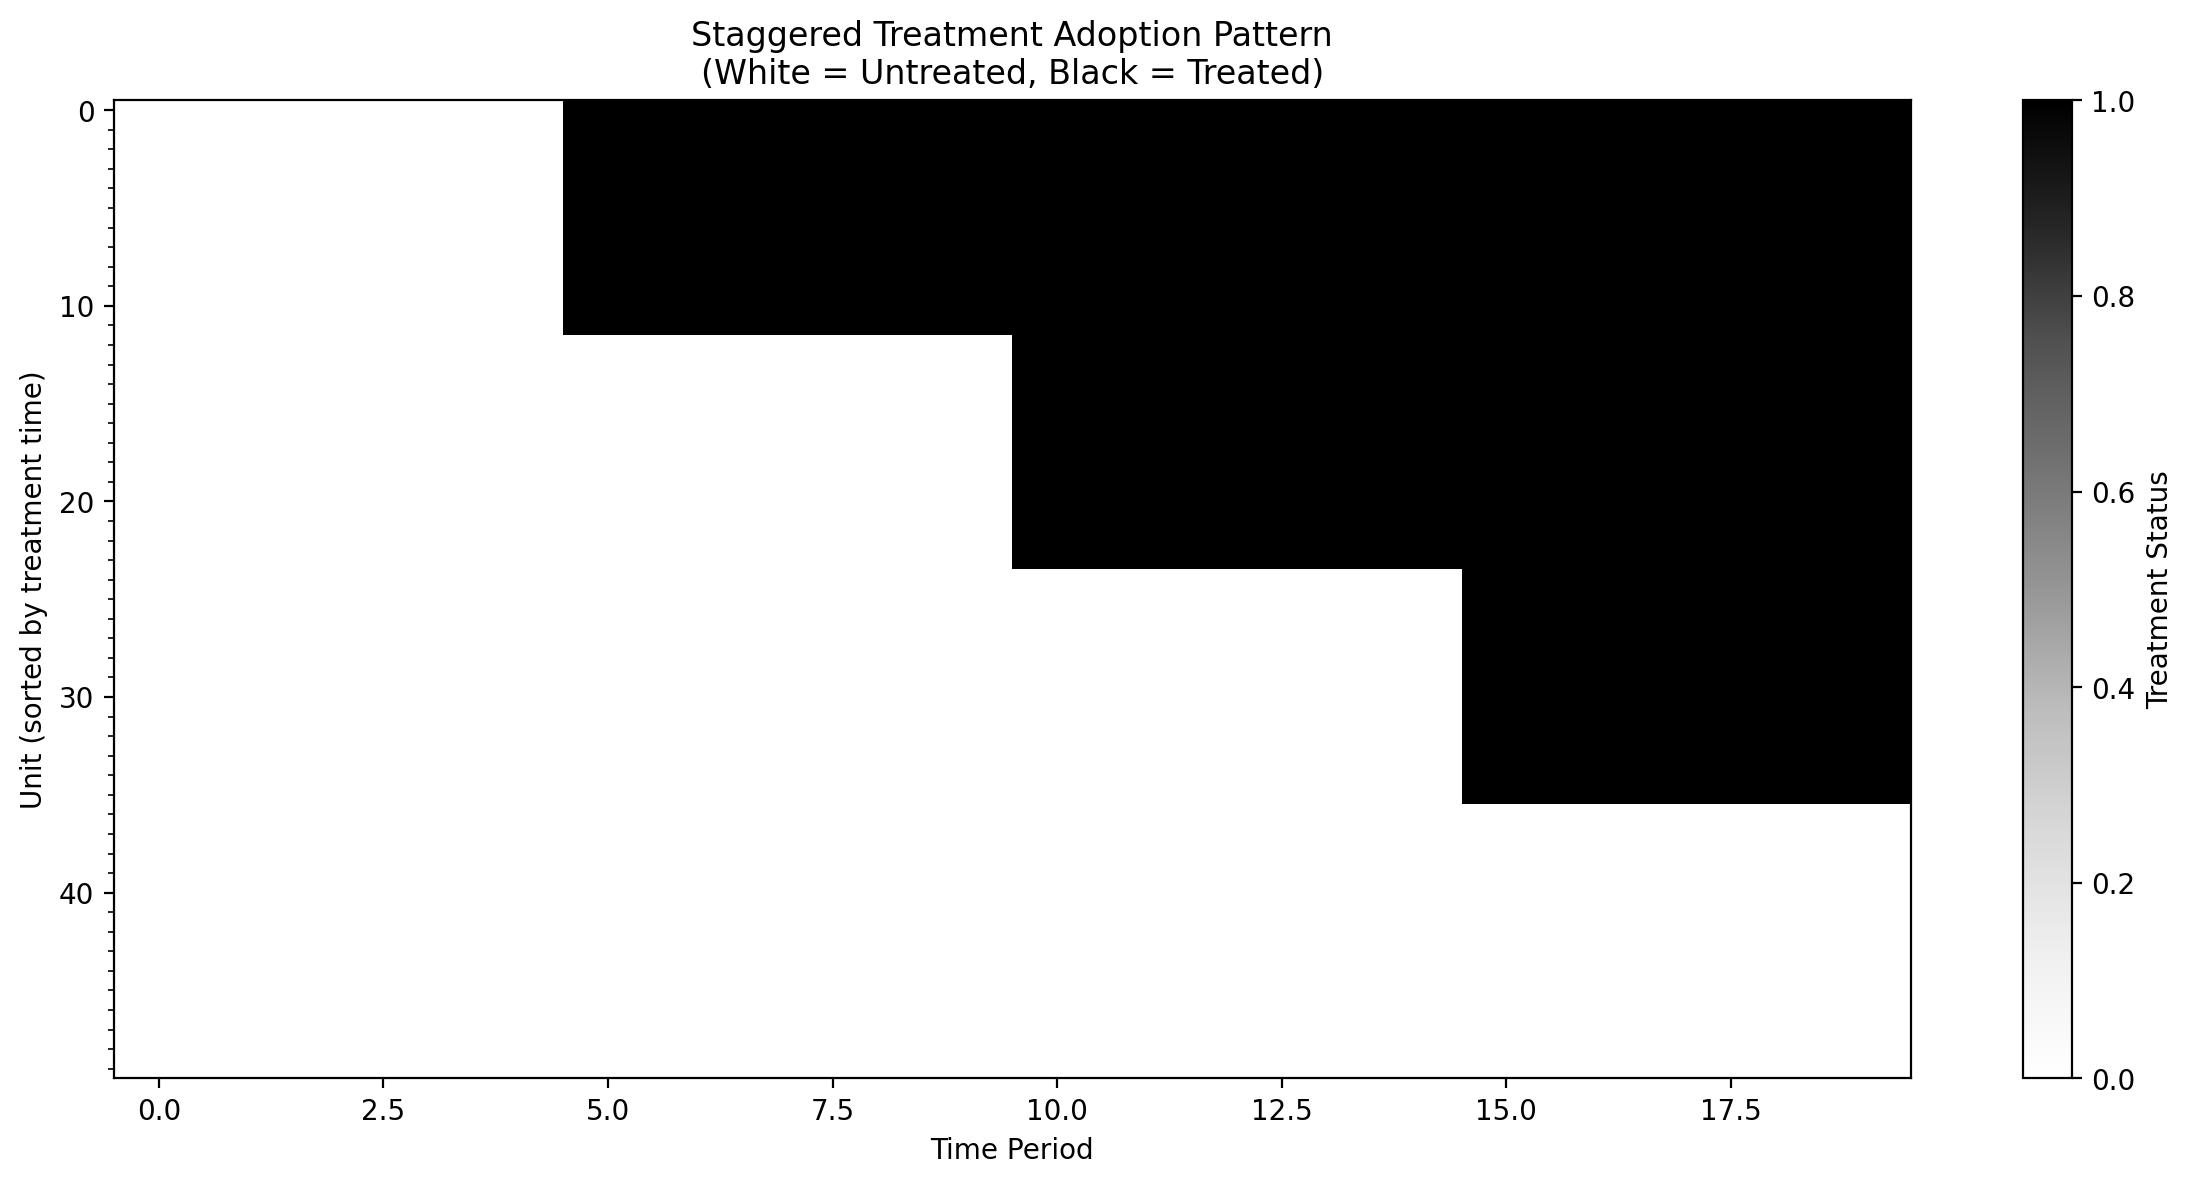

In [21]:
from matplotlib.ticker import MultipleLocator

# Create a heatmap of treatment status
fig, ax = plt.subplots(figsize=(12, 6))

# Pivot to get unit x time matrix of treatment status
treatment_matrix = df.pivot(index="unit", columns="time", values="treated")

# Sort by treatment time for better visualization
unit_treatment_times = df.groupby("unit")["treatment_time"].first().sort_values()
treatment_matrix = treatment_matrix.loc[unit_treatment_times.index]

im = ax.imshow(
    treatment_matrix.values,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
ax.set_xlabel("Time Period")
ax.set_ylabel("Unit (sorted by treatment time)")
ax.set_title(
    "Staggered Treatment Adoption Pattern\n(White = Untreated, Black = Treated)"
)

ax.yaxis.set_minor_locator(MultipleLocator(1))
plt.colorbar(im, ax=ax, label="Treatment Status")
plt.tight_layout()
plt.show()

## Fit the Staggered DiD Model

We'll use a model with unit and time fixed effects, which is the baseline counterfactual model for imputation.

The formula defines a model of **untreated potential outcomes**. Crucially, this model is fitted only on observations that are not yet treated: pre-treatment periods for units that eventually receive treatment, plus all periods for never-treated units. The fitted model is then used to predict what the treated units *would have* experienced in the absence of treatment (the counterfactual). Treatment effects are computed as the difference between observed outcomes and these counterfactual predictions.

The formula `y ~ 1 + C(unit) + C(time)` specifies a two-way fixed effects model, but you're not limited to this specification. If you have additional covariates that help explain variation in the outcome—such as weather conditions, seasonality indicators, economic indicators, or any other time-varying controls—you can include them in the formula. For example, `y ~ 1 + C(unit) + C(time) + temperature + holiday` would add temperature and holiday effects to the model. Including relevant covariates can improve the precision of your treatment effect estimates and strengthen the plausibility of the parallel trends assumption.


In [22]:
# Fit the staggered DiD model with PyMC
result = cp.StaggeredDifferenceInDifferences(
    df,
    formula="y ~ 1 + C(unit) + C(time)",
    unit_variable_name="unit",
    time_variable_name="time",
    treated_variable_name="treated",
    treatment_time_variable_name="treatment_time",
    model=cp.pymc_models.LinearRegression(
        sample_kwargs={
            "progressbar": True,
            "random_seed": 42,
        }
    ),
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]


## Event-Study Plot

The event-study plot shows estimates at each event-time (time relative to treatment). Key features:

- **Pre-treatment placebo estimates** (event-time < 0, gray squares): These should be close to zero if the parallel trends assumption holds. They are computed as residuals (observed minus predicted) for eventually-treated units before they receive treatment. These are **not** treatment effects—they are fit diagnostics.
- **Post-treatment ATT estimates** (event-time ≥ 0, blue circles): These are the actual Average Treatment effect on the Treated (ATT) estimates showing the dynamic treatment effect over time since treatment.
- **Error bars**: 94% Highest Density Intervals (HDI) from the Bayesian posterior
- **Gray shaded region**: Pre-treatment period (placebo check zone)

:::{note}
Since we generated synthetic data with known treatment effects, we can overlay the true effects on the plot to validate the estimator's performance. In real applications, the true effects are unknown.
:::

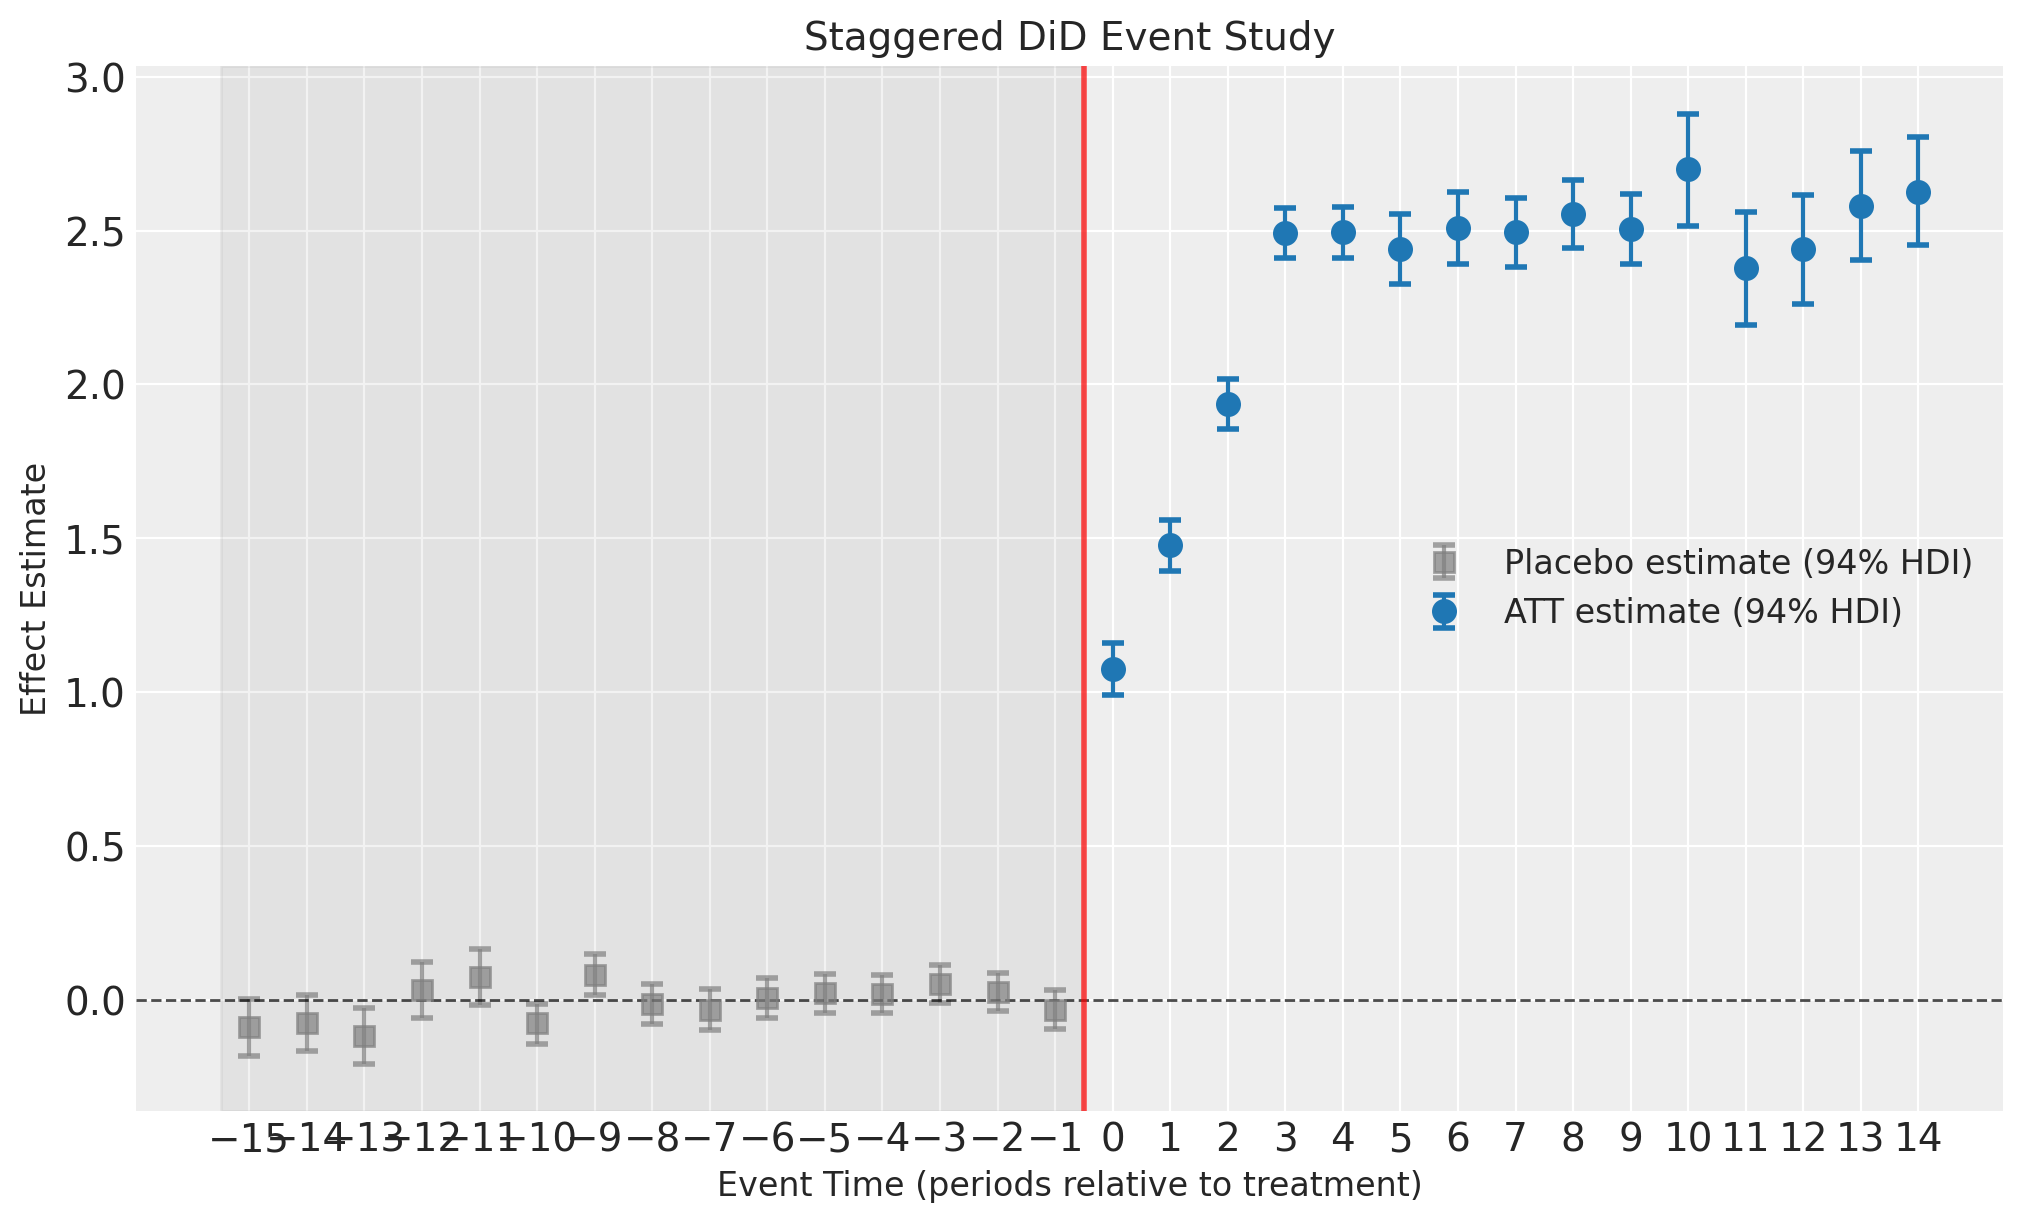

In [23]:
fig, ax = result.plot()

# Overlay true treatment effects (only possible because we simulated the data)
att_et = result.att_event_time_
post_treatment = att_et[att_et["event_time"] >= 0]
true_vals = [TRUE_EFFECTS.get(e, 2.5) for e in post_treatment["event_time"]]
ax[0].scatter(
    post_treatment["event_time"],
    true_vals,
    color="red",
    marker="x",
    s=100,
    linewidths=2,
    zorder=5,
    label="True Effect",
)
ax[0].legend()

plt.show()

## View Summary Statistics

The `n_obs` column in the event-time ATT table shows the number of treated unit-time observations contributing to each event-time estimate. This varies across event-times because different cohorts have different lengths of post-treatment history. For example, units treated early in the panel contribute observations at all event-times, while units treated later only contribute to earlier event-times (e.g., event-time 0, 1, 2) before the panel ends.


In [24]:
result.summary(round_to=2)

======================Staggered Difference in Differences=======================
Formula: y ~ 1 + C(unit) + C(time)
Number of units: 50
Number of time periods: 20
Treatment cohorts: [np.float64(5.0), np.float64(10.0), np.float64(15.0)]
Never-treated units: 14

Event-time estimates:
 event_time    type       att  att_lower  att_upper  n_obs
        -15 placebo -0.089727  -0.182651   0.001678     12
        -14 placebo -0.076510  -0.165531   0.015464     12
        -13 placebo -0.117002  -0.208039  -0.026421     12
        -12 placebo  0.030745  -0.059782   0.121330     12
        -11 placebo  0.074539  -0.016959   0.164344     12
        -10 placebo -0.076136  -0.143237  -0.012652     24
         -9 placebo  0.081386   0.014587   0.148938     24
         -8 placebo -0.013679  -0.080336   0.051946     24
         -7 placebo -0.032442  -0.098791   0.033575     24
         -6 placebo  0.004729  -0.060527   0.071197     24
         -5 placebo  0.021254  -0.042810   0.082547     36
         

We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [25]:
from maketables import ETable

ETable(result, coef_fmt="b:.3f")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x13c8ee270>

## Effect Summary

Get a prose summary of the causal effects. The summary includes the average post-treatment effect, and if pre-treatment placebo effects are available, it reports on whether the parallel trends assumption appears to be satisfied:


In [26]:
effect_summary = result.effect_summary()
print(effect_summary.text)

Staggered DiD analysis: The average post-treatment effect across event-times was 2.31 (average 94% HDI [2.19, 2.44]). Pre-treatment placebo check: Average pre-treatment effect was -0.01, consistent with parallel trends assumption. Analysis includes 3 treatment cohort(s).


## Pre-Treatment Placebo Check

The `att_event_time_` table includes pre-treatment event times (negative values). These represent the average **residuals** (observed - predicted) for eventually-treated units *before* they receive treatment.

:::{important}
Pre-treatment estimates are **not** ATT (Average Treatment effect on the Treated). They are **placebo/fit diagnostics** that validate the counterfactual model and parallel trends assumption. If these values are close to zero, it suggests the model fits well and parallel trends is plausible.
:::


In [27]:
# Separate pre- and post-treatment effects
att_et = result.att_event_time_
pre_treatment = att_et[att_et["event_time"] < 0]
post_treatment = att_et[att_et["event_time"] >= 0]

print("Pre-treatment (placebo) effects:")
print(f"  Mean: {pre_treatment['att'].mean():.3f}")
print("  Should be close to zero if parallel trends holds")
print()
print("Post-treatment effects:")
print(f"  Mean: {post_treatment['att'].mean():.3f}")
print(f"  True average effect: {np.mean(list(TRUE_EFFECTS.values())):.3f}")

Pre-treatment (placebo) effects:
  Mean: -0.009
  Should be close to zero if parallel trends holds

Post-treatment effects:
  Mean: 2.313
  True average effect: 1.750


## Examine the Event-Time ATT Table

The `att_event_time_` attribute provides direct access to the underlying event-time ATT estimates as a pandas DataFrame. This is the same data visualized in the event-study plot, but in tabular form.

**When to use this table:**

- **Reporting precise estimates**: When you need exact point estimates and credible intervals for a paper or presentation, rather than reading approximate values from a plot.
- **Custom analysis**: When you want to perform additional calculations on the estimates, such as computing cumulative effects, testing specific hypotheses, or comparing effects at particular event-times.
- **Debugging and validation**: When checking that the model is behaving as expected, or comparing estimates across different model specifications.
- **Exporting results**: When you need to save estimates to a file or integrate them into a larger analysis pipeline.

The table includes `event_time` (periods relative to treatment), `type` (placebo vs ATT), point estimates (`att`), credible/confidence intervals, and `n_obs` (sample size at each event-time).


In [28]:
result.att_event_time_

,event_time,att,att_lower,att_upper,n_obs
0,-15,-0.089727,-0.182651,0.001678,12
1,-14,-0.076510,-0.165531,0.015464,12
2,-13,-0.117002,-0.208039,-0.026421,12
3,-12,0.030745,-0.059782,0.121330,12
4,-11,0.074539,-0.016959,0.164344,12
5,-10,-0.076136,-0.143237,-0.012652,24
6,-9,0.081386,0.014587,0.148938,24
7,-8,-0.013679,-0.080336,0.051946,24
8,-7,-0.032442,-0.098791,0.033575,24
9,-6,0.004729,-0.060527,0.071197,24


## Group-Time ATT Table

The `att_group_time_` attribute provides the most granular level of treatment effect estimates: effects for each combination of treatment cohort (G) and calendar time (t). This is the "building block" data from which event-time effects are aggregated.

**Understanding the difference from event-time effects:**

- **Event-time ATT** (`att_event_time_`): Aggregates effects across cohorts at the same *relative* time since treatment (e.g., "effect 2 periods after treatment" averages over all cohorts).
- **Group-time ATT** (`att_group_time_`): Keeps cohort and calendar time separate, showing effects for specific cohort-time pairs (e.g., "effect for cohort treated at t=5, observed at t=7").

**When to use this table:**

- **Cohort heterogeneity analysis**: When you suspect treatment effects differ across cohorts (e.g., early adopters vs late adopters respond differently to treatment).
- **Calendar time effects**: When you want to check if treatment effects vary with calendar time, not just time since treatment (e.g., macroeconomic conditions may amplify or dampen effects).
- **Diagnostics**: When event-time effects look suspicious and you want to trace the issue back to specific cohort-time combinations.
- **Custom aggregation**: When you want to compute alternative summary measures (e.g., cohort-specific average effects, or effects weighted by cohort size).

The table includes `cohort` (treatment time G), `time` (calendar time t), and treatment effect estimates with uncertainty intervals:


In [29]:
result.att_group_time_.head(20)

,cohort,time,att,att_lower,att_upper
0,5.0,5,1.105831,0.981070,1.234096
1,5.0,6,1.313366,1.191865,1.438411
2,5.0,7,1.874254,1.738034,2.002803
3,5.0,8,2.324531,2.195446,2.449806
4,5.0,9,2.495319,2.365605,2.621871
5,5.0,10,2.330355,2.188604,2.468263
6,5.0,11,2.469498,2.326770,2.611914
7,5.0,12,2.452538,2.311010,2.599357
8,5.0,13,2.521460,2.381104,2.661465
9,5.0,14,2.492747,2.348853,2.636524


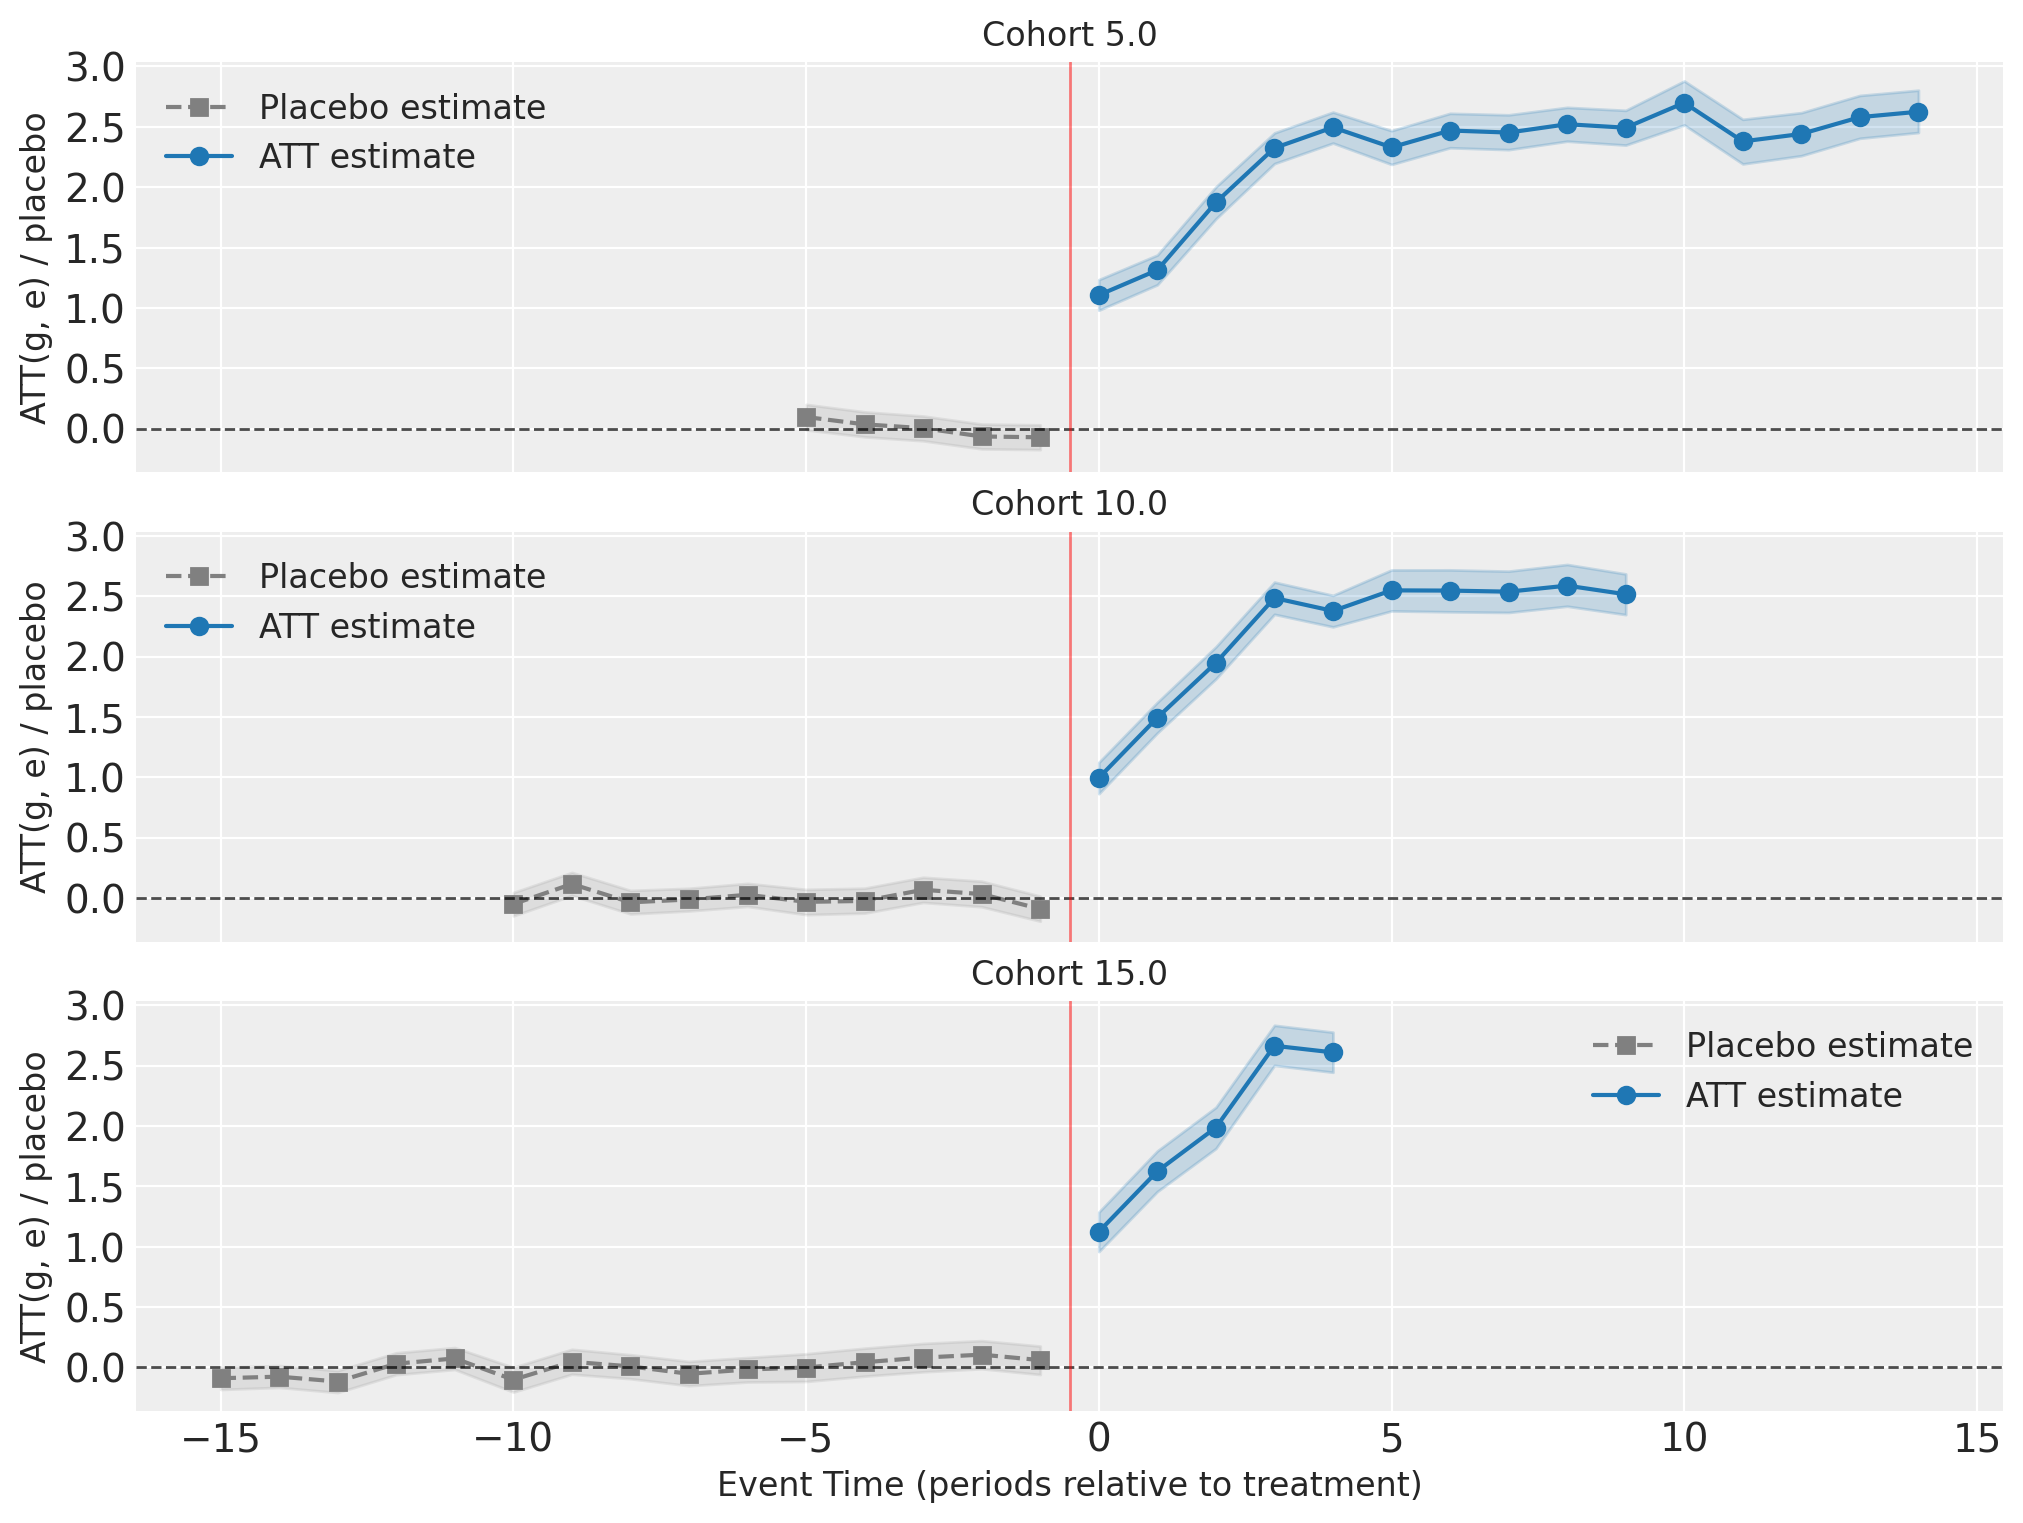

In [30]:
fig, ax = result.plot_group_time()
plt.show()

The cohort-trajectory plot keeps the `ATT(g, t)` estimates disaggregated and displays them as an `ATT(g, e)` view by converting calendar time to event time (`e = t - g`). Each row follows one treatment cohort, with the Bayesian uncertainty band showing posterior uncertainty for that cohort-time estimand.

Use this view when cohort-level heterogeneity is substantively important or when you want to audit what the collapsed event-study curve is averaging over. The event-study plot is still useful as a compact summary, but it combines cohorts that are observed at the same event-time; when cohort composition changes across event-times, the aggregate curve can reflect both treatment dynamics and the weighting induced by which cohorts are still observed. If calendar time is the more relevant scale, pass `x_axis="calendar_time"`; if you want all cohorts on one axes, pass `layout="overlay"`.

## Using scikit-learn Models

For faster analysis, you can use scikit-learn models instead of PyMC. The error bars represent approximate 95% confidence intervals (±1.96 standard errors).

```python
from sklearn.linear_model import LinearRegression

result_ols = cp.StaggeredDifferenceInDifferences(
    df,
    formula="y ~ 1 + C(unit) + C(time)",
    unit_variable_name="unit",
    time_variable_name="time",
    treated_variable_name="treated",
    treatment_time_variable_name="treatment_time",
    model=LinearRegression(),
)

# Plot the event-study results
fig, ax = result_ols.plot()
plt.show()
```

The OLS approach produces similar point estimates to the Bayesian model but runs much faster. However, the uncertainty quantification differs: OLS uses asymptotic standard errors while PyMC provides full posterior distributions.


## Key Takeaways

1. **Staggered adoption requires special handling** - standard TWFE can produce biased estimates

2. **The imputation approach** fits a model on untreated observations and predicts counterfactuals

3. **Event-study curves** show dynamic treatment effects and allow for parallel trends checks

4. **Pre-treatment "placebo" estimates** (event-time < 0) are **not** treatment effects—they are fit diagnostics. Values near zero support the parallel trends assumption.

5. **Post-treatment ATT estimates** (event-time ≥ 0) are the actual Average Treatment effect on the Treated

6. **CausalPy supports both Bayesian and OLS** approaches for flexibility


## Sensitivity analysis

### Pre-treatment placebo check

The parallel trends assumption is the key identification condition in difference-in-differences: in the absence of treatment, treated and control units would have followed the same trajectory. This assumption cannot be tested directly, but we can probe it by examining **pre-treatment event-study estimates** — the residuals for eventually-treated units in the periods before they receive treatment {cite:p}`borusyak2024revisiting`.

The `PreTreatmentPlaceboCheck` formalises this validation. It inspects the pre-treatment event-time ATT estimates already computed by the staggered DiD model and tests whether their mean is close to zero. Since pre-treatment periods should show no treatment effect, any systematic deviation from zero suggests a violation of the parallel trends assumption.

**How it works.** The check extracts all event-time estimates with negative event-time values (pre-treatment periods) from `att_event_time_`. It computes the mean and maximum absolute pre-treatment ATT and applies a threshold-based test.

**Interpreting the output.** If the mean pre-treatment ATT is close to zero, the check **passes**, providing evidence consistent with parallel trends. If it deviates, the check **fails**, suggesting that the counterfactual model may be mis-specified or that the groups were already diverging before treatment. Note that this is a necessary but not sufficient condition: passing the pre-treatment check does not guarantee that parallel trends would have held in the post-treatment period {cite:p}`goodman2021difference`.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]


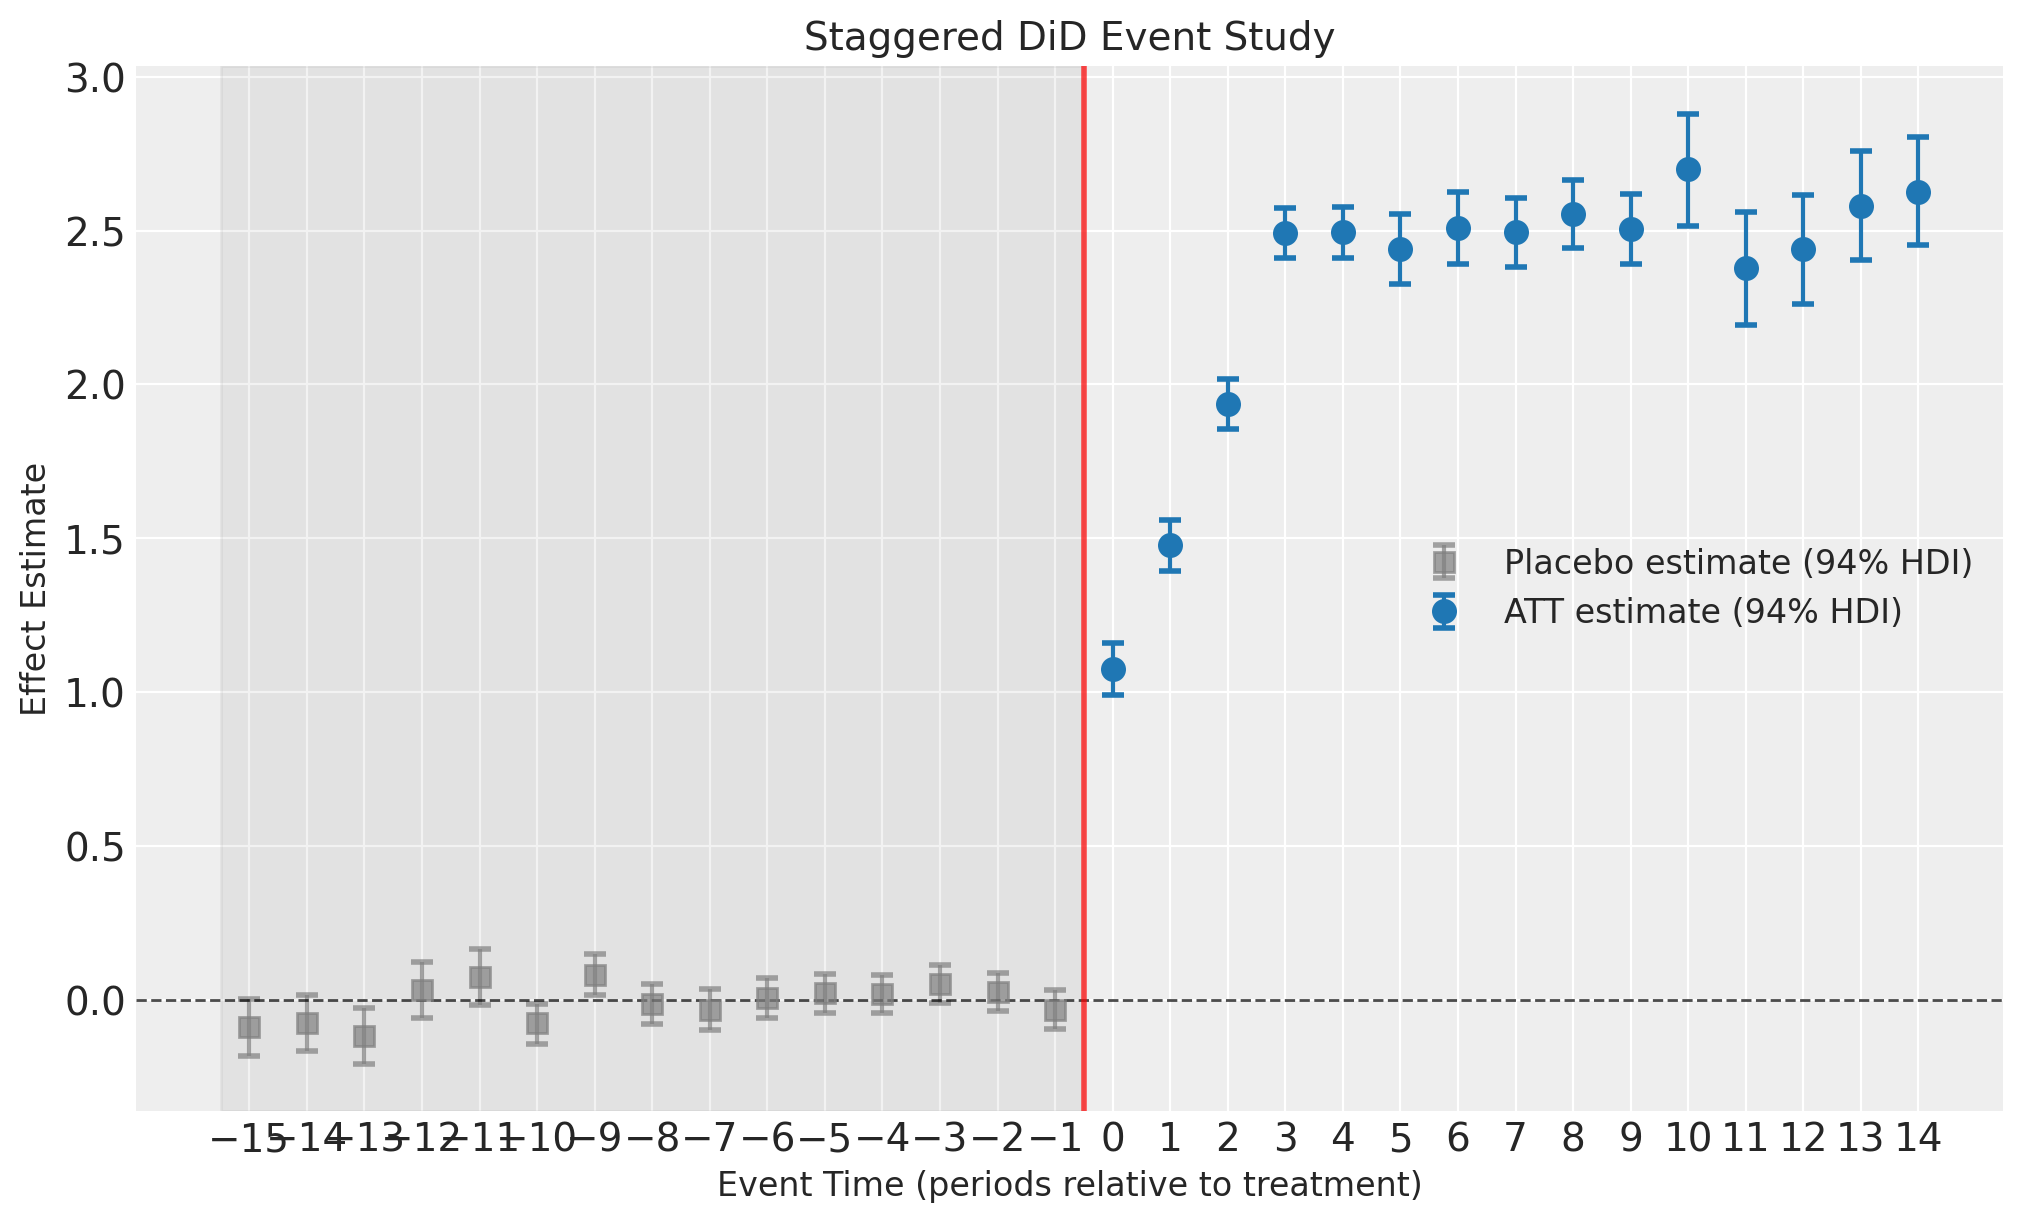

Pre-treatment placebo check failed: mean pre-treatment ATT = -0.0089, suggesting possible violation of the parallel trends assumption.


In [31]:
sensitivity_result = cp.Pipeline(
    data=df,
    steps=[
        cp.EstimateEffect(
            method=cp.StaggeredDifferenceInDifferences,
            formula="y ~ 1 + C(unit) + C(time)",
            unit_variable_name="unit",
            time_variable_name="time",
            treated_variable_name="treated",
            treatment_time_variable_name="treatment_time",
            model=cp.pymc_models.LinearRegression(
                sample_kwargs={"progressbar": True, "random_seed": 42}
            ),
        ),
        cp.SensitivityAnalysis(
            checks=[cp.checks.PreTreatmentPlaceboCheck(threshold=0.05)],
        ),
        cp.GenerateReport(include_plots=True),
    ],
).run()

for cr in sensitivity_result.sensitivity_results:
    print(cr.text)


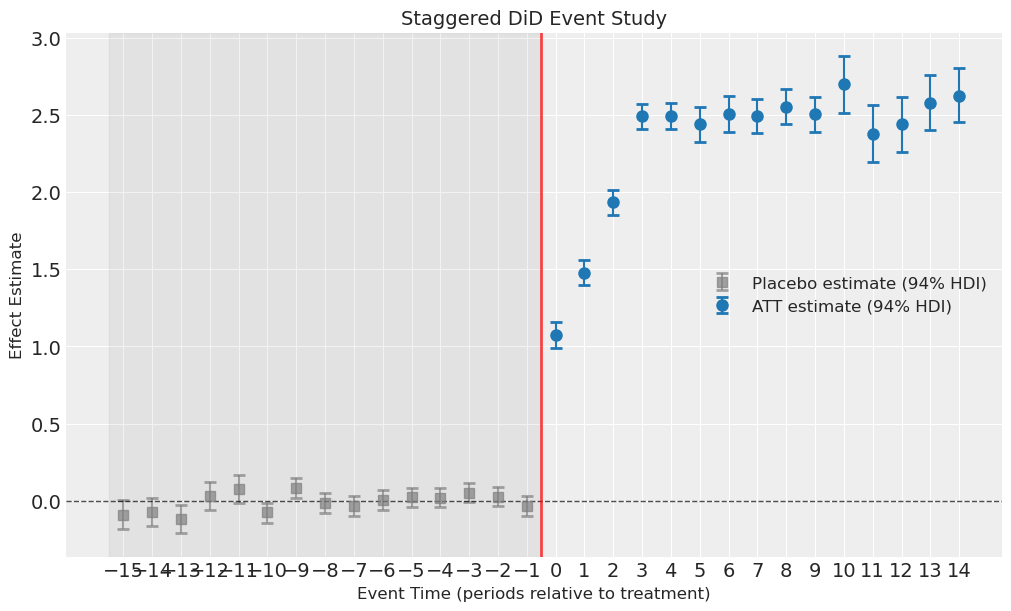

In [32]:
import html as html_module
import warnings

from IPython.display import HTML

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", "Consider using IPython.display.IFrame", UserWarning
    )
    display(
        HTML(
            f'<iframe srcdoc="{html_module.escape(sensitivity_result.report)}" '
            f'width="100%" height="600" style="border:1px solid #ccc;"></iframe>'
        )
    )